# Auditoría real del dataset Embat v2

## tl;dr

Los recuentos y claves principales cuadran, pero la cobertura temporal es desigual, parte de los movimientos apunta a productos de deuda, los snapshots de saldo usan cinco fechas y la semántica de facturas/FX no permite DSO, DPO ni consolidación fiable. El detalle normativo está en `DATA_QUALITY.md`.

## Context & Methods

### Key Assumptions

- Una ausencia de mes no es actividad cero.
- `created_at` es onboarding, no constitución.
- La auditoría usa los CSV reales y preserva importes por moneda.

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import pyarrow as pa

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / "artifacts").is_dir())
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"blue": "#3568D4", "gold": "#C8942F", "orange": "#D96C2F", "charcoal": "#262B33"}

## Data

Inventario, hashes y controles de clave generados por `embat_analysis.audit`.

In [2]:
inventory = pl.read_parquet(ROOT / "artifacts/audit/inventory.parquet")
keys = pl.read_parquet(ROOT / "artifacts/audit/primary_keys.parquet")
orphans = pl.read_parquet(ROOT / "artifacts/audit/referential_integrity.parquet")
inventory.select("file", "rows", "bytes"), keys, orphans

(shape: (9, 3)
 ┌──────────────────────────┬─────────┬───────────┐
 │ file                     ┆ rows    ┆ bytes     │
 │ ---                      ┆ ---     ┆ ---       │
 │ str                      ┆ i64     ┆ i64       │
 ╞══════════════════════════╪═════════╪═══════════╡
 │ groups.csv               ┆ 250     ┆ 5243      │
 │ companies.csv            ┆ 1286    ┆ 70591     │
 │ banking_products.csv     ┆ 5987    ┆ 596360    │
 │ debt_products.csv        ┆ 2239    ┆ 268287    │
 │ debt_schedule_config.csv ┆ 87      ┆ 12922     │
 │ transactions.csv         ┆ 2556437 ┆ 472353364 │
 │ invoices.csv             ┆ 897894  ┆ 172547599 │
 │ balances.csv             ┆ 7996    ┆ 480768    │
 │ data_dictionary.md       ┆ 0       ┆ 5883      │
 └──────────────────────────┴─────────┴───────────┘,
 shape: (7, 5)
 ┌──────────────────────┬────────────────┬─────────┬────────────────┬───────────┐
 │ table                ┆ key            ┆ rows    ┆ duplicate_keys ┆ null_keys │
 │ ---                  ┆

## Results

### Cobertura mensual observada

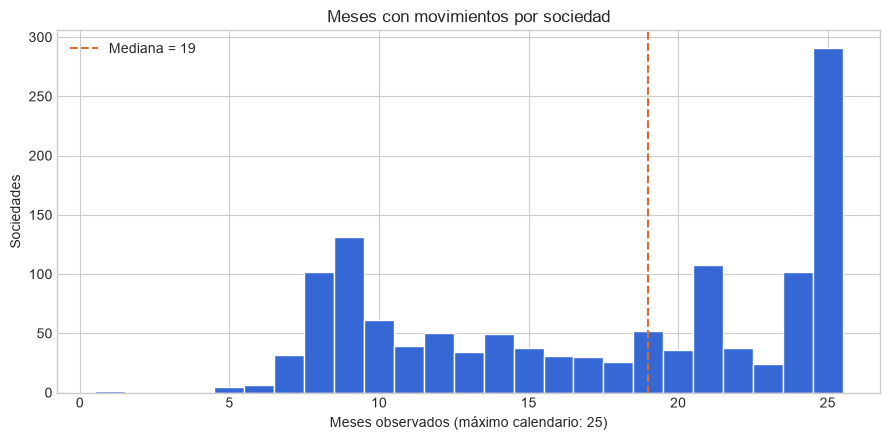

statistic,value
str,f64
"""count""",1286.0
"""null_count""",0.0
"""mean""",17.246501
"""std""",6.601666
"""min""",1.0
"""25%""",10.0
"""50%""",19.0
"""75%""",24.0
"""max""",25.0


In [3]:
coverage = pl.read_parquet(ROOT / "artifacts/audit/transaction_coverage.parquet")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(coverage["observed_months"].to_numpy(), bins=np.arange(0.5, 26.5, 1), color=COLORS["blue"], edgecolor="white")
ax.set(title="Meses con movimientos por sociedad", xlabel="Meses observados (máximo calendario: 25)", ylabel="Sociedades")
ax.axvline(19, color=COLORS["orange"], linestyle="--", label="Mediana = 19")
ax.legend()
plt.tight_layout()
plt.show()
coverage["observed_months"].describe()

### Faltantes estructurales

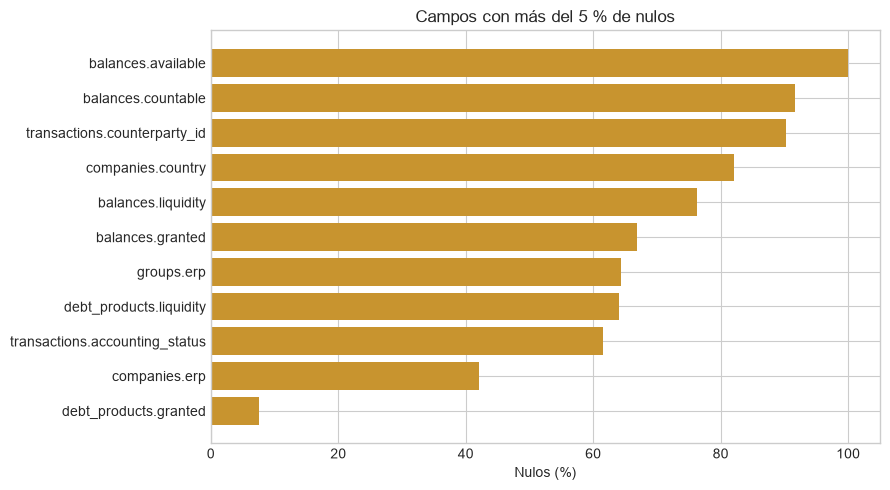

table,column,inferred_type,null_count,null_rate
str,str,str,i64,f64
"""balances""","""available""","""VARCHAR""",7996,1.0
"""balances""","""countable""","""DOUBLE""",7332,0.916958
"""transactions""","""counterparty_id""","""VARCHAR""",2305659,0.901903
"""companies""","""country""","""VARCHAR""",1056,0.821151
"""balances""","""liquidity""","""DOUBLE""",6100,0.762881
…,…,…,…,…
"""groups""","""erp""","""VARCHAR""",161,0.644
"""debt_products""","""liquidity""","""DOUBLE""",1435,0.640911
"""transactions""","""accounting_status""","""VARCHAR""",1573869,0.615649


In [4]:
nulls = pl.read_parquet(ROOT / "artifacts/audit/null_profile.parquet")
top_nulls = nulls.filter(pl.col("null_rate") > 0.05).sort("null_rate").tail(12)
fig, ax = plt.subplots(figsize=(9, 5))
labels = (top_nulls["table"] + "." + top_nulls["column"]).to_list()
ax.barh(labels, top_nulls["null_rate"].to_numpy() * 100, color=COLORS["gold"])
ax.set(title="Campos con más del 5 % de nulos", xlabel="Nulos (%)")
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()
top_nulls.sort("null_rate", descending=True)

## Takeaways

1. El dataset permite análisis de flujo observado por sociedad/mes/moneda.
2. No permite tratar toda ausencia como cero ni asumir 24 meses homogéneos.
3. DSO/DPO, FX consolidado y caja histórica quedan bloqueados hasta resolver semántica y anomalías.
4. La calidad se exporta separada del score financiero.